In [1]:
#import relevant libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
from collections import defaultdict
from matplotlib.patches import Circle
import matplotlib.font_manager as fm

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
# File processing
workcomp = "C:\\Users\\User"
laptop = "C:\\Users\\lnico"
officecomp = "C:\\Users\\Star"
homecomp = "D:"
specifiedpath = workcomp

filepath = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Together\\3. Compiled\\"
openPath = specifiedpath + filepath
files2 = os.listdir(openPath)

In [4]:
# Set up Inter font
inter_font_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Regular.ttf"
inter_bold_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Bold.ttf"
inter_italic_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Italic.ttf"

# Register fonts
import matplotlib.font_manager as fm
fm.fontManager.addfont(inter_font_path)
fm.fontManager.addfont(inter_bold_path)
fm.fontManager.addfont(inter_italic_path)

# Set Inter as default font
plt.rcParams['font.family'] = 'Inter'

## formulas

In [5]:
def darken_color(hex_color, factor=0.6):
    """Darken a hex color by multiplying RGB values by factor (0-1)"""
    hex_color = hex_color.lstrip('#')
    rgb = tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (0, 2, 4))
    darkened_rgb = tuple(max(0, min(1, c * factor)) for c in rgb)
    return '#{:02x}{:02x}{:02x}'.format(
        int(darkened_rgb[0] * 255),
        int(darkened_rgb[1] * 255),
        int(darkened_rgb[2] * 255)
    )


def calculate_grouped_positions(matched_crosses, within_spacing=1.2, between_spacing=0.8):
    """Calculate x-positions with driver-based grouping. All columns have equal width."""
    driver_groups = defaultdict(list)
    for i, item in enumerate(matched_crosses):
        base_cross = item[-1] if isinstance(item, tuple) else item
        driver = base_cross.split(' x ')[0]
        driver_groups[driver].append(i)
    
    cell_width = within_spacing  # equal to spacing so boxes sit edge-to-edge
    
    positions = []
    current_position = 0
    sorted_drivers = sorted(driver_groups.keys(), key=lambda d: min(driver_groups[d]))
    
    for driver_idx, driver in enumerate(sorted_drivers):
        for idx in driver_groups[driver]:
            positions.append(current_position)
            current_position += within_spacing
        if driver_idx < len(sorted_drivers) - 1:
            current_position += between_spacing
    
    # Reorder to match original order
    position_mapping = {}
    counter = 0
    for driver in sorted_drivers:
        for idx in driver_groups[driver]:
            position_mapping[idx] = positions[counter]
            counter += 1
    
    final_positions = [position_mapping[i] for i in range(len(matched_crosses))]
    final_cell_widths = [cell_width] * len(matched_crosses)
    return final_positions, driver_groups, final_cell_widths

def parse_responders_with_atr(matched_crosses):
    """Parse cross names to extract base responders and ATR flags."""
    drivers, responders_base, has_atr = [], [], []
    
    for item in matched_crosses:
        base_cross = item[-1] if isinstance(item, tuple) else item
        parts = base_cross.split(' x ')
        if len(parts) >= 2:
            drivers.append(parts[0])
            responder_full = parts[1].strip()
            if ' allstats' in responder_full:
                responder_full = responder_full.split(' allstats')[0].strip()
            
            if '[ATR]' in responder_full:
                responders_base.append(responder_full.replace('[ATR]', '').strip())
                has_atr.append(True)
            else:
                responders_base.append(responder_full)
                has_atr.append(False)
    
    # Build unique responders list (preserve order)
    unique_responders = list(dict.fromkeys(responders_base))
    if any(has_atr):
        unique_responders.append('ATR')
    
    return drivers, responders_base, has_atr, unique_responders

def draw_table_grid(ax, positions, row_y_positions, cell_widths, cell_height, total_rows):
    """Draw table grid rectangles. cell_widths can be a list (per-position) or scalar."""
    import matplotlib.patches as patches
    for i, center_pos in enumerate(positions):
        cw = cell_widths[i] if isinstance(cell_widths, list) else cell_widths
        for row_idx in range(total_rows):
            rect = patches.Rectangle(
                (center_pos - cw/2, row_y_positions[row_idx]),
                cw, cell_height,
                linewidth=1, edgecolor='black', facecolor='white'
            )
            ax.add_patch(rect)

def place_table_dots_and_n(ax, positions, matched_crosses, responders_base, has_atr, 
                           unique_responders, row_y_positions, cell_height, 
                           singlemeandiff, markersize, fontsize):
    """Place dots in responder rows and sample sizes in N row."""
    total_rows = len(row_y_positions)
    
    for i, center_pos in enumerate(positions):
        # Place responder dot
        base_responder = responders_base[i]
        if base_responder in unique_responders:
            row_idx = unique_responders.index(base_responder)
            y_center = row_y_positions[row_idx] + (cell_height * 0.5)
            ax.plot(center_pos, y_center, 'ko', markersize=markersize)
        
        # Place ATR dot if applicable
        if has_atr[i] and 'ATR' in unique_responders:
            atr_row_idx = unique_responders.index('ATR')
            y_center_atr = row_y_positions[atr_row_idx] + (cell_height * 0.5)
            ax.plot(center_pos, y_center_atr, 'ko', markersize=markersize)
        
        # Sample size in N's row (shifted slightly down from center)
        cross_full = matched_crosses[i][0]
        sample_size = singlemeandiff[singlemeandiff['cross'] == cross_full]['samplesize'].iloc[0]
        n_row_y = row_y_positions[total_rows - 1] + (cell_height * 0.35)
        ax.text(center_pos, n_row_y, str(sample_size), ha='center', va='center', 
                fontsize=fontsize, fontfamily='Inter')

def add_table_labels(ax, positions, unique_responders, row_y_positions, cell_height,
                     driver_groups, cell_widths, fontsize_table, fontsize_driver):
    """Add row labels and driver labels with grouping lines."""
    total_rows = len(row_y_positions)
    max_cw = max(cell_widths) if isinstance(cell_widths, list) else cell_widths
    label_x = min(positions) - max_cw * 0.6
    
    # Responder row labels
    for row_idx, responder in enumerate(unique_responders):
        y_center = row_y_positions[row_idx] + (cell_height * 0.5)
        ax.text(label_x, y_center, responder, ha='right', va='center', 
                fontsize=fontsize_table, fontfamily='Inter')
    
    # N's row label
    n_row_y = row_y_positions[total_rows - 1] + (cell_height * 0.5)
    ax.text(label_x, n_row_y, "N's", ha='right', va='center', 
            fontsize=fontsize_table, fontfamily='Inter')
    
    # Driver labels with grouping lines
    for driver, indices in driver_groups.items():
        if indices:
            x_positions = [positions[i] for i in indices]
            widths = [cell_widths[i] if isinstance(cell_widths, list) else cell_widths for i in indices]
            x_start = min(x_positions) - widths[0] / 2
            x_end = max(x_positions) + widths[-1] / 2
            y_pos = row_y_positions[total_rows - 1] - (cell_height * 0.25)
            
            ax.plot([x_start, x_end], [y_pos, y_pos], 'k-', linewidth=1)
            ax.text(np.mean(x_positions), y_pos - (cell_height * 0.25), driver, 
                    ha='center', va='top', fontsize=fontsize_driver, style='italic', fontfamily='Inter')

def format_main_axes(ax, positions, ylim, fontsize_tick):
    """Apply common main axes formatting."""
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.set_ylim(ylim)
    y_min, y_max = ylim
    ax.set_yticks(np.arange(np.ceil(y_min), np.floor(y_max) + 1, 1))
    ax.tick_params(axis='y', labelsize=fontsize_tick)
    if positions:
        ax.set_xlim(min(positions) - 1.0, max(positions) + 1.0)
    ax.grid(False)
    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)
    ax.set_xticks([])

def cleanup_table_axes(ax):
    """Clean up table axes."""
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

def pergenotypeplotting(openPath, files2, k, effect_type='hedgesg'):
    """Unified function for processing genotype data."""
    metricname = pd.DataFrame()
    singlemeandiff = pd.DataFrame()

    effect_col = k + "_Hedgesg" if effect_type == 'hedgesg' else k + "_deltag"
    effect_label = 'Hedgesg' if effect_type == 'hedgesg' else 'deltag'

    for f in files2:
        newfile2read = pd.read_csv(openPath + f, index_col=0)
        cross = (f.replace("_wtcomparison.csv", "")
                 .replace(" allstats.csv", "")
                  .replace("eOPN3", "AsOPN3")
                  .replace("[B]", "")
                  .replace("(iii)M4", ""))

        samplefile = pd.DataFrame({
            'bootstrap': newfile2read[k+"_bootstrap"],
            effect_label: newfile2read[effect_col],
            'Cross': cross,
            'metric': k,
            'samplesize': newfile2read['Sample_size']
        })

        singlemeans = pd.DataFrame({
            'mean': samplefile[effect_label].unique(),
            'cross': cross,
            'samplesize': newfile2read['Sample_size'].unique(),
            'err': samplefile['bootstrap'].mean() - (samplefile['bootstrap'].mean() - 1.96*(np.std(samplefile['bootstrap'])))
        })

        metricname = pd.concat([metricname, samplefile], axis=0)
        singlemeandiff = pd.concat([singlemeandiff, singlemeans], axis=0)

    return metricname, singlemeandiff

# Backward-compatible wrapper functions
def pergenotypeplotting_deltag(openPath, files2, k):
    return pergenotypeplotting(openPath, files2, k, effect_type='deltag')

def pergenotypeplotting_hedgesg(openPath, files2, k):
    return pergenotypeplotting(openPath, files2, k, effect_type='hedgesg')

## Table for paired plot

In [ ]:
def forestplot_paired_phases_table(metricname_full, singlemeandiff_full, metricname_recovery, singlemeandiff_recovery, 
                                   gridkey1=None, gridkey2=None, figsize=(10, 6), 
                                   violin_1_color="#2ECA13", violin_2_color="#727272", ylim=(-5.0, 0),
                                   fontsize=None, markersize=None):
    
    # Scaling
    scale_factor = ((figsize[0] / 10) + (figsize[1] / 6)) / 2
    fontsize_ylabel = fontsize if fontsize else int(14 * scale_factor)
    fontsize_tick = fontsize if fontsize else int(12 * scale_factor)
    fontsize_value = fontsize if fontsize else 9
    fontsize_table = fontsize if fontsize else int(9 * scale_factor)
    fontsize_driver = fontsize if fontsize else int(9 * scale_factor)
    fontsize_legend = fontsize if fontsize else int(8 * scale_factor)
    markersize_dot = markersize if markersize else int(7 * scale_factor)
    markersize_errorbar = markersize if markersize else int(6 * scale_factor)
    linewidth_error, linewidth_connect = 2 * scale_factor, 2 * scale_factor
    within_spacing, between_spacing = 1.2, 0.8
    
    # Colors
    color_full, color_recovery = violin_1_color, violin_2_color
    color_full_text, color_recovery_text = darken_color(color_full), darken_color(color_recovery)

    # Match crosses between phases
    matched_crosses = []
    for cross_full in singlemeandiff_full['cross'].unique():
        base_cross = cross_full.replace('_DARK_FULL', '').replace('_DARK_RECOVERY', '')
        for cross_recovery in singlemeandiff_recovery['cross'].unique():
            if cross_recovery.replace('_DARK_FULL', '').replace('_DARK_RECOVERY', '') == base_cross:
                matched_crosses.append((cross_full, cross_recovery, base_cross))
                break
    
    # Calculate positions and parse responders
    positions, driver_groups, cell_widths = calculate_grouped_positions(matched_crosses, within_spacing, between_spacing)
    _, responders_base, has_atr, unique_responders = parse_responders_with_atr(matched_crosses)
    
    # Create figure and axes
    fig = plt.figure(figsize=figsize)
    ax_main = plt.subplot2grid((7, 1), (0, 0), rowspan=5)
    ax_table = plt.subplot2grid((7, 1), (5, 0), rowspan=2)
    
    # Plot paired violins
    for i, (cross_full, cross_recovery, _) in enumerate(matched_crosses):
        full_pos, recovery_pos = positions[i] - 0.25, positions[i] + 0.25
        
        full_data = metricname_full[metricname_full['Cross'] == cross_full]['bootstrap']
        recovery_data = metricname_recovery[metricname_recovery['Cross'] == cross_recovery]['bootstrap']
        full_mean = singlemeandiff_full[singlemeandiff_full['cross'] == cross_full]['mean'].iloc[0]
        full_err = singlemeandiff_full[singlemeandiff_full['cross'] == cross_full]['err'].iloc[0]
        recovery_mean = singlemeandiff_recovery[singlemeandiff_recovery['cross'] == cross_recovery]['mean'].iloc[0]
        recovery_err = singlemeandiff_recovery[singlemeandiff_recovery['cross'] == cross_recovery]['err'].iloc[0]

        # Full phase violin
        parts = ax_main.violinplot([full_data], positions=[full_pos], widths=0.4, showmeans=False, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color_full); pc.set_alpha(0.85); pc.set_edgecolor('none')
            pc.get_paths()[0].vertices[:, 0] = np.maximum(pc.get_paths()[0].vertices[:, 0], full_pos)
        
        # Recovery phase violin
        parts = ax_main.violinplot([recovery_data], positions=[recovery_pos], widths=0.4, showmeans=False, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color_recovery); pc.set_alpha(0.85); pc.set_edgecolor('none')
            pc.get_paths()[0].vertices[:, 0] = np.maximum(pc.get_paths()[0].vertices[:, 0], recovery_pos)
        
        # Error bars, connecting line, labels
        ax_main.errorbar(full_pos, full_mean, yerr=full_err, fmt='o', color='black', markersize=markersize_errorbar, capsize=0, elinewidth=linewidth_error)
        ax_main.errorbar(recovery_pos, recovery_mean, yerr=recovery_err, fmt='o', color='black', markersize=markersize_errorbar, capsize=0, elinewidth=linewidth_error)
        ax_main.plot([full_pos, recovery_pos], [full_mean, recovery_mean], color='black', alpha=0.4, linewidth=linewidth_connect)
        ax_main.text(full_pos - 0.1, full_mean, f'{full_mean:.2f}', ha='right', va='center', fontsize=fontsize_value, color=color_full_text, fontweight='bold', fontfamily='Inter')
        ax_main.text(recovery_pos + 0.1, recovery_mean, f'{recovery_mean:.2f}', ha='left', va='top', fontsize=fontsize_value, color=color_recovery_text, fontweight='bold', fontfamily='Inter')
    
    # Format main axes
    ax_main.set_ylabel("Δg of " + metricname_full['metric'].unique()[0], fontweight='bold', fontsize=fontsize_ylabel, fontfamily='Inter')
    format_main_axes(ax_main, positions, ylim, fontsize_tick)
    
    # Phase legend
    ax_main.text(1.02, 0.98, 'DARK:LIGHT ON', ha='left', va='top', fontsize=fontsize_legend, color=color_full_text, fontweight='bold', fontfamily='Inter', transform=ax_main.transAxes)
    ax_main.text(1.02, 0.90, 'DARK:RECOVERY', ha='left', va='top', fontsize=fontsize_legend, color=color_recovery_text, fontweight='bold', fontfamily='Inter', transform=ax_main.transAxes)
    
    # Table setup
    total_table_rows = len(unique_responders) + 1
    cell_height = 0.75 / total_table_rows
    row_y_positions = [0.75 - (i * cell_height) for i in range(total_table_rows)]
    
    ax_table.set_xlim(min(positions) - 1, max(positions) + 1)
    ax_table.set_ylim(0, 1)
    
    # Draw table components using helpers
    draw_table_grid(ax_table, positions, row_y_positions, cell_widths, cell_height, total_table_rows)
    place_table_dots_and_n(ax_table, positions, matched_crosses, responders_base, has_atr, unique_responders, row_y_positions, cell_height, singlemeandiff_full, markersize_dot, fontsize_table)
    add_table_labels(ax_table, positions, unique_responders, row_y_positions, cell_height, driver_groups, cell_widths, fontsize_table, fontsize_driver)
    cleanup_table_axes(ax_table)
    
    mpl.rcParams['svg.fonttype'] = 'none'
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.05)
    return fig

In [ ]:
# Generate paired phase plots with TABLE format
lstnamings = ['speed', 'height']

files_full = [f'elav x ACR [ATR] allstats_DARK_FULL.csv', f'elav x eOPN3 allstats_DARK_FULL.csv',  
              f'46416jus x ACR [ATR] allstats_DARK_FULL.csv', f'46416jus x eOPN3 allstats_DARK_FULL.csv',f'46416jus x eOPN3 [ATR] allstats_DARK_FULL.csv',
                f'vGlut x ACR [ATR] allstats_DARK_FULL.csv', f'vGlut x eOPN3 allstats_DARK_FULL.csv', f'vGlut x eOPN3 [ATR] allstats_DARK_FULL.csv',
              f'nSyb x eOPN3 allstats_DARK_FULL.csv', f'nSyb x eOPN3 [ATR] allstats_DARK_FULL.csv']

files_recovery = [f.replace('_DARK_FULL', '_DARK_RECOVERY') for f in files_full]

for n in lstnamings:
    dfmn_full, dfsmd_full = pergenotypeplotting_hedgesg(openPath, files_full, n)
    dfmn_recovery, dfsmd_recovery = pergenotypeplotting_hedgesg(openPath, files_recovery, n)

    print(f"Creating table-based paired phases plot for {n}...")
    g_table = forestplot_paired_phases_table(
        dfmn_full.replace("ACR", "GtACR1", regex=True), 
        dfsmd_full.replace("ACR", "GtACR1", regex=True), 
        dfmn_recovery.replace("ACR", "GtACR1", regex=True), 
        dfsmd_recovery.replace("ACR", "GtACR1", regex=True), 
        "GtACR1", "AsOPN3", figsize=(14,6), violin_1_color="#00AF54", ylim=(-7, 1.0),
        fontsize=None, markersize=None)
    
    mpl.rcParams['svg.fonttype'] = 'none' 
    #g_table.savefig(titledpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\forestplot_table_paired_phases_" + n + ".svg", bbox_inches="tight") 
    plt.show()

## table for single phase

In [58]:
def get_responder_color(cross_name):
    
    cross_lower = cross_name.lower()
    if 'acr' in cross_lower or 'gtacr' in cross_lower:
        color = "#1AB80B"
        noatrcolor= "#7FC801FF"
    elif 'asopn3' in cross_lower or 'eopn3' in cross_lower:
        color = "#07527A"
        noatrcolor= "#19BBDFFF"
    else:
        color = "#888888"
    
    has_atr = '[ATR]' in cross_name or '[atr]' in cross_name
    return color, noatrcolor, has_atr

def forestplot_single_phase_table(metricname_full, singlemeandiff_full, gridkey1=None, gridkey2=None, 
                                  figsize=(10, 8), violin_color="#00AF54", ylim=(-4.0, 0), 
                                  ratio=[0.7, 0.3], hspace=0, fontsize=None, markersize=None):
    
    # Validate ratio
    if len(ratio) != 2 or sum(ratio) + hspace > 1.0 or any(r <= 0 for r in ratio) or hspace < 0:
        raise ValueError("Invalid ratio/hspace parameters")

    # Scaling
    scale_factor = ((figsize[0] / 10) + (figsize[1] / 8)) / 2
    ratio_scale = ratio[1] / 0.3
    fontsize_ylabel = fontsize if fontsize else int(14 * scale_factor)
    fontsize_tick = fontsize if fontsize else int(12 * scale_factor)
    fontsize_value = fontsize if fontsize else 11
    fontsize_table = fontsize if fontsize else int(11 * scale_factor * ratio_scale)
    fontsize_driver = fontsize if fontsize else int(10 * scale_factor * ratio_scale)
    markersize_dot = markersize if markersize else int(6 * scale_factor * ratio_scale)
    markersize_errorbar = markersize if markersize else int(6 * scale_factor)
    linewidth_error = 2 * scale_factor
    within_spacing, between_spacing = 1.2, 0.8

    # Match crosses
    matched_crosses = [(c, c.replace('_DARK_FULL', '').replace('_DARK_RECOVERY', '')) 
                       for c in singlemeandiff_full['cross'].unique()]
    
    # Calculate positions and parse responders
    positions, driver_groups, cell_widths = calculate_grouped_positions(matched_crosses, within_spacing, between_spacing)
    _, responders_base, has_atr, unique_responders = parse_responders_with_atr(matched_crosses)
    
    # Create figure with custom ratio
    fig = plt.figure(figsize=figsize)
    total_grid = 100
    main_rows = int(ratio[0] * total_grid)
    hspace_rows = int(hspace * total_grid)
    table_rows = int(ratio[1] * total_grid)
    
    ax_main = plt.subplot2grid((total_grid, 1), (0, 0), rowspan=main_rows)
    ax_table = plt.subplot2grid((total_grid, 1), (main_rows + hspace_rows, 0), rowspan=table_rows)
    
    # Plot single violins
    for i, (cross_full, _) in enumerate(matched_crosses):
        pos = positions[i]
        
        full_data = metricname_full[metricname_full['Cross'] == cross_full]['bootstrap']
        full_mean = singlemeandiff_full[singlemeandiff_full['cross'] == cross_full]['mean'].iloc[0]
        full_err = singlemeandiff_full[singlemeandiff_full['cross'] == cross_full]['err'].iloc[0]
        
        # Determine color and fill style based on responder and ATR
        resp_color, resp_no_atr, resp_has_atr = get_responder_color(cross_full)
        
        
        parts = ax_main.violinplot([full_data], positions=[pos], widths=0.6, showmeans=False, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            if resp_has_atr:
                # ATR present: filled violin
                pc.set_facecolor(resp_color)
                pc.set_alpha(0.75)
                pc.set_edgecolor('none')
                color_text = darken_color(resp_color)
            else:
                # No ATR: outline only
                pc.set_facecolor(resp_no_atr)
                pc.set_alpha(0.65)
                pc.set_edgecolor(resp_no_atr)
                pc.set_linewidth(0.8)
                color_text = darken_color(resp_no_atr)
            pc.get_paths()[0].vertices[:, 0] = np.maximum(pc.get_paths()[0].vertices[:, 0], pos)
        
        ax_main.errorbar(pos, full_mean, yerr=full_err, fmt='o', color='black', markersize=markersize_errorbar, capsize=0, elinewidth=linewidth_error)
        ax_main.text(pos - 0.1, full_mean, f'{full_mean:.2f}', ha='right', va='center', fontsize=fontsize_value, color=color_text, fontweight='bold', fontfamily='Inter')
    
    # Format main axes
    ax_main.set_ylabel("Δg of " + metricname_full['metric'].unique()[0], fontweight='bold', fontsize=fontsize_ylabel, fontfamily='Inter')
    format_main_axes(ax_main, positions, ylim, fontsize_tick)
    
    # Table setup
    total_table_rows = len(unique_responders) + 1
    cell_height = 0.50 / total_table_rows
    row_y_positions = [0.75 - (i * cell_height) for i in range(total_table_rows)]
    
    ax_table.set_xlim(min(positions) - 1, max(positions) + 1)
    ax_table.set_ylim(0, 1)
    
    # Draw table components using helpers
    draw_table_grid(ax_table, positions, row_y_positions, cell_widths, cell_height, total_table_rows)
    place_table_dots_and_n(ax_table, positions, matched_crosses, responders_base, has_atr, unique_responders, row_y_positions, cell_height, singlemeandiff_full, markersize_dot, fontsize_table)
    add_table_labels(ax_table, positions, unique_responders, row_y_positions, cell_height, driver_groups, cell_widths, fontsize_table, fontsize_driver)
    cleanup_table_axes(ax_table)
    
    mpl.rcParams['svg.fonttype'] = 'none'
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.05)
    return fig

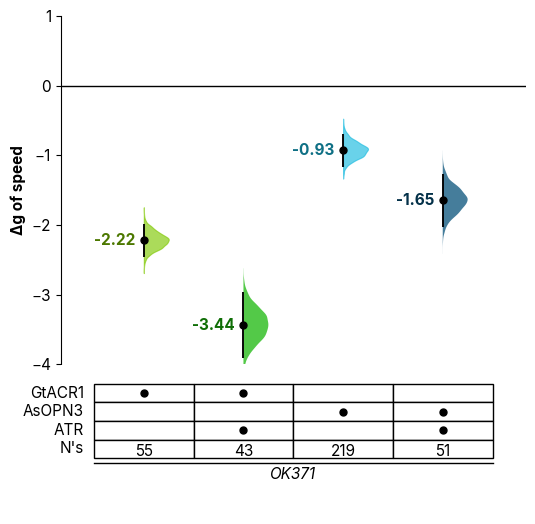

In [59]:
# Generate paired phase plots with TABLE format
lstnamings = ['speed']  #height or speed

files_wt = [f'OK371 x ACR allstats_DARK_FULL.csv', f'OK371 x ACR [ATR] allstats_DARK_FULL.csv',  
            f'OK371 x eOPN3 allstats_DARK_FULL.csv', f'OK371 x eOPN3 [ATR] allstats_DARK_FULL.csv'
            ] 
files_full = [f.replace('.csv', '_wtcomparison.csv') for f in files_wt]

for n in lstnamings:
    dfmn_full, dfsmd_full = pergenotypeplotting_deltag(openPath, files_full, n)

    g_table = forestplot_single_phase_table(
        dfmn_full.replace("ACR", "GtACR1", regex=True), 
        dfsmd_full.replace("ACR", "GtACR1", regex=True), 
        "GtACR1", "AsOPN3", figsize=(6,6), violin_color="#0FA334", ylim=(-4, 1.0),
        fontsize=11, markersize=5)
    
    mpl.rcParams['svg.fonttype'] = 'none' 
    #g_table.savefig(specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\forestplot_table_single_phases_OK37l" + n + ".svg", bbox_inches="tight") 
    plt.show()

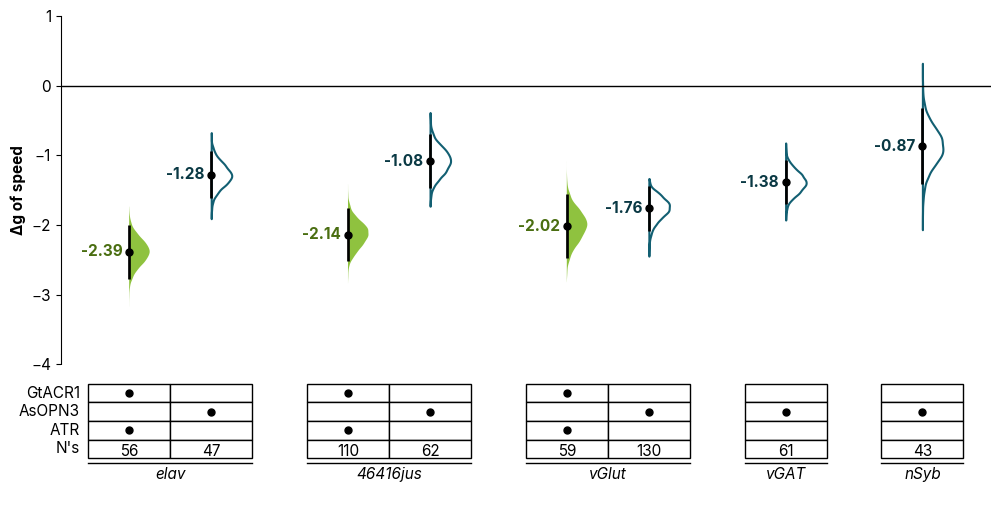

In [9]:
# Generate paired phase plots with TABLE format
lstnamings = ['speed']  #height or speed

files_wt = [f'elav x ACR [ATR] allstats_DARK_FULL.csv', f'elav x eOPN3 allstats_DARK_FULL.csv',  
            f'46416jus x ACR [ATR] allstats_DARK_FULL.csv', f'46416jus x eOPN3 allstats_DARK_FULL.csv',
                f'vGlut x ACR [ATR] allstats_DARK_FULL.csv', f'vGlut x eOPN3 allstats_DARK_FULL.csv', 
                f'vGAT x eOPN3 allstats_DARK_FULL.csv', 
                f'nSyb x eOPN3 allstats_DARK_FULL.csv'] 
files_full = [f.replace('.csv', '_wtcomparison.csv') for f in files_wt]

for n in lstnamings:
    dfmn_full, dfsmd_full = pergenotypeplotting_deltag(openPath, files_full, n)

    g_table = forestplot_single_phase_table(
        dfmn_full.replace("ACR", "GtACR1", regex=True), 
        dfsmd_full.replace("ACR", "GtACR1", regex=True), 
        "GtACR1", "AsOPN3", figsize=(12,6), violin_color="#0FA334", ylim=(-4, 1.0),
        fontsize=11, markersize=5)
    
    mpl.rcParams['svg.fonttype'] = 'none' 
    #g_table.savefig(specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\forestplot_table_single_phases_total" + n + ".svg", bbox_inches="tight") 
    plt.show()

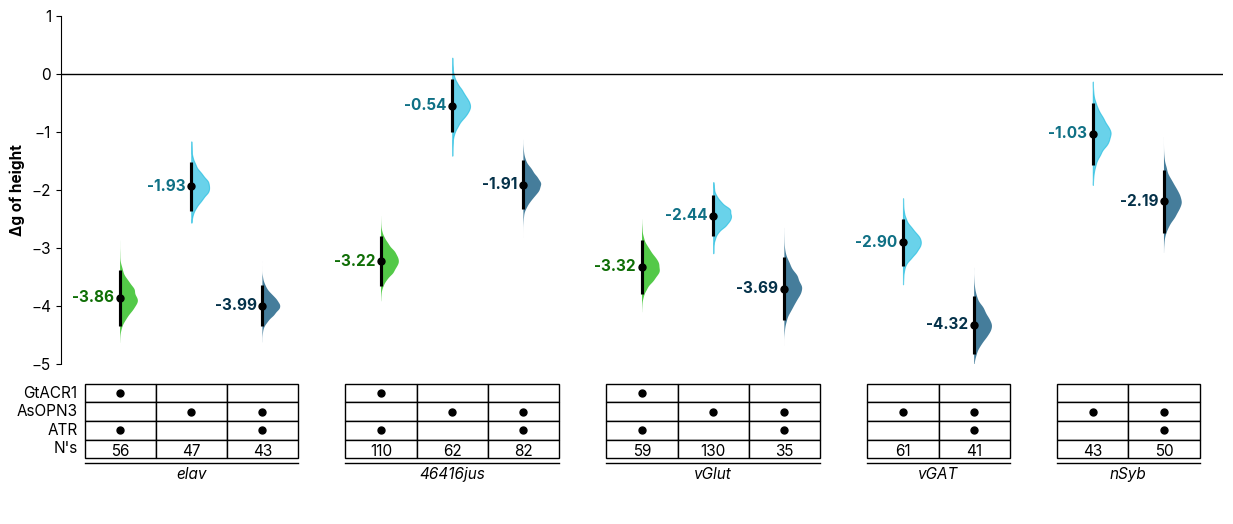

In [61]:
# Generate paired phase plots with TABLE format
lstnamings = ['height']  #height or speed

files_wt = [f'elav x ACR [ATR] allstats_DARK_FULL.csv', f'elav x eOPN3 allstats_DARK_FULL.csv',   f'elav x eOPN3 [ATR] allstats_DARK_FULL.csv', 
              f'46416jus x ACR [ATR] allstats_DARK_FULL.csv', f'46416jus x eOPN3 allstats_DARK_FULL.csv',f'46416jus x eOPN3 [ATR] allstats_DARK_FULL.csv',
                f'vGlut x ACR [ATR] allstats_DARK_FULL.csv', f'vGlut x eOPN3 allstats_DARK_FULL.csv', f'vGlut x eOPN3 [ATR] allstats_DARK_FULL.csv',
                f'vGAT x eOPN3 allstats_DARK_FULL.csv', f'vGAT x eOPN3 [ATR] allstats_DARK_FULL.csv',
              f'nSyb x eOPN3 allstats_DARK_FULL.csv', f'nSyb x eOPN3 [ATR] allstats_DARK_FULL.csv']

files_full = [f.replace('.csv', '_wtcomparison.csv') for f in files_wt]

for n in lstnamings:
    dfmn_full, dfsmd_full = pergenotypeplotting_deltag(openPath, files_full, n)

    g_table = forestplot_single_phase_table(
        dfmn_full.replace("ACR", "GtACR1", regex=True), 
        dfsmd_full.replace("ACR", "GtACR1", regex=True), 
        "GtACR1", "AsOPN3", figsize=(15,6), violin_color="#0FA334", ylim=(-5, 1.0),
        fontsize=11, markersize=5)
    
    mpl.rcParams['svg.fonttype'] = 'none' 
    g_table.savefig(specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\forestplot_table_single_phases_total" + n + ".svg", bbox_inches="tight") 
    plt.show()

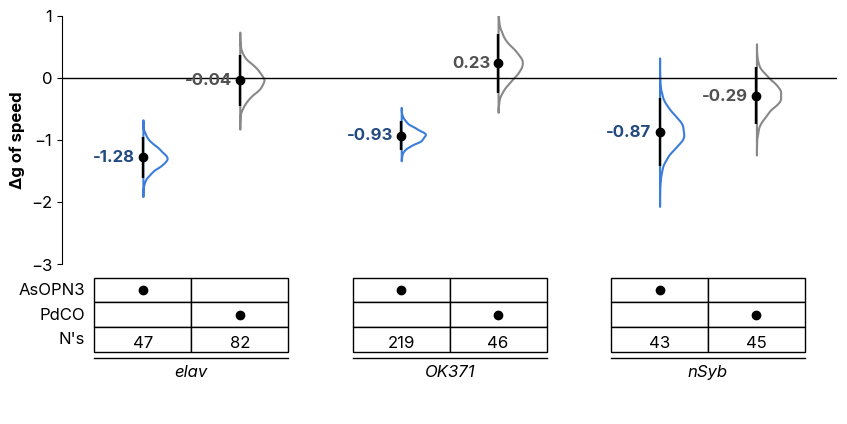

In [12]:
lstnamings = ['speed']  #height or speed

##wt comparison
files_wt = [f'elav x eOPN3 allstats_DARK_FULL.csv', f'elav x PdCO allstats_DARK_FULL.csv',                  
                f'OK371 x eOPN3 allstats_DARK_FULL.csv', f'OK371 x PdCO allstats_DARK_FULL.csv', 
              f'nSyb x eOPN3 allstats_DARK_FULL.csv', f'nSyb x PdCO allstats_DARK_FULL.csv']

files_full = [f.replace('.csv', '_wtcomparison.csv') for f in files_wt]

for n in lstnamings:
    # Process both phases
    dfmn_full, dfsmd_full = pergenotypeplotting_deltag(openPath, files_full, n)

    g_table = forestplot_single_phase_table(
        dfmn_full.replace("ACR", "GtACR1", regex=True), 
        dfsmd_full.replace("ACR", "GtACR1", regex=True), 
        "AsOPN3", "PdCO", figsize=(10,6), violin_color="#BBAFFF", ylim=(-3, 1.0), ratio=[0.5, 0.3],
        fontsize=12, markersize=6)
    
    mpl.rcParams['svg.fonttype'] = 'none' 
    g_table.savefig(specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\forestplot_PdCO_" + n + ".svg", bbox_inches="tight") 
    plt.show()

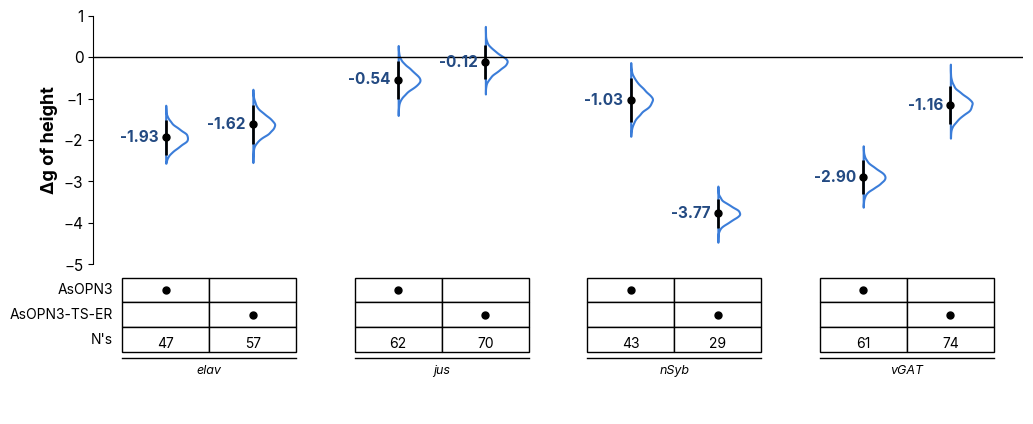

In [53]:
lstnamings = ['height']  #height or speed

##wt comparison
files_wt = [ f'elav x eOPN3 allstats_DARK_FULL.csv', f'elav x eOPN3-TS-ER allstats_DARK_FULL.csv',   
                f'46416jus x eOPN3 allstats_DARK_FULL.csv', f'46416jus x eOPN3-TS-ER allstats_DARK_FULL.csv', 
                          
              f'nSyb x eOPN3 allstats_DARK_FULL.csv', f'nSyb x eOPN3-TS-ER allstats_DARK_FULL.csv', 
               f'vGAT x eOPN3 allstats_DARK_FULL.csv', f'vGAT x eOPN3-TS-ER allstats_DARK_FULL.csv'
             ]

files_full = [f.replace('.csv', '_wtcomparison.csv') for f in files_wt]

for n in lstnamings:
    # Process both phases
    dfmn_full, dfsmd_full = pergenotypeplotting_deltag(openPath, files_full, n)

    g_table = forestplot_single_phase_table(
        dfmn_full.replace("ACR", "GtACR1", regex=True).replace("46416jus", "jus", regex=True), 
        dfsmd_full.replace("ACR", "GtACR1", regex=True).replace("46416jus", "jus", regex=True), 
        "AsOPN3", "ATR", figsize=(12,6), violin_color="#F03A3A", ylim=(-5, 1.0), ratio=[0.5, 0.3],
        fontsize=None, markersize=None)
    
    mpl.rcParams['svg.fonttype'] = 'none' 
    g_table.savefig(specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\forestplot_table_single_phases_ts_er_" + n + ".svg", bbox_inches="tight") 
    plt.show()

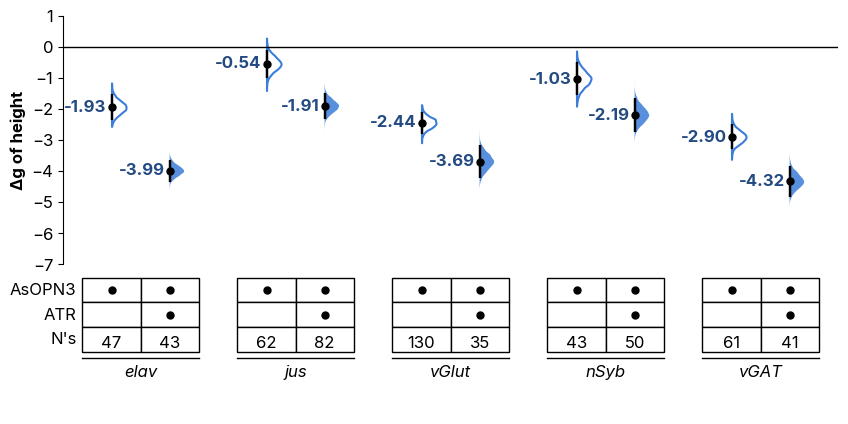

In [16]:
lstnamings = ['height']  #height or speed

##wt comparison
files_wt = [ f'elav x eOPN3 allstats_DARK_FULL.csv', f'elav x eOPN3 [ATR] allstats_DARK_FULL.csv',   
                f'46416jus x eOPN3 allstats_DARK_FULL.csv', f'46416jus x eOPN3 [ATR] allstats_DARK_FULL.csv', 
                f'vGlut x eOPN3 allstats_DARK_FULL.csv', f'vGlut x eOPN3 [ATR] allstats_DARK_FULL.csv', 
              f'nSyb x eOPN3 allstats_DARK_FULL.csv', f'nSyb x eOPN3 [ATR] allstats_DARK_FULL.csv', 
               f'vGAT x eOPN3 allstats_DARK_FULL.csv', f'vGAT x eOPN3 [ATR] allstats_DARK_FULL.csv']

files_full = [f.replace('.csv', '_wtcomparison.csv') for f in files_wt]

for n in lstnamings:
    # Process both phases
    dfmn_full, dfsmd_full = pergenotypeplotting_deltag(openPath, files_full, n)

    g_table = forestplot_single_phase_table(
        dfmn_full.replace("ACR", "GtACR1", regex=True).replace("46416jus", "jus", regex=True), 
        dfsmd_full.replace("ACR", "GtACR1", regex=True).replace("46416jus", "jus", regex=True), 
        "AsOPN3", "ATR", figsize=(10,6), violin_color="#3ACBF0", ylim=(-7, 1.0), ratio=[0.5, 0.3],
        fontsize=12, markersize=None)
    
    mpl.rcParams['svg.fonttype'] = 'none' 
    g_table.savefig(specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\forestplot_table_single_phases (NOATR)_" + n + ".svg", bbox_inches="tight") 
    plt.show()

In [ ]:
lstnamings = ['speed']  #height or speed

##wt comparison
files_wt = [ f'elav x ACR [ATR] allstats_DARK_FULL.csv', f'elav x eOPN3 [ATR] allstats_DARK_FULL.csv',   
                f'46416jus x ACR [ATR] allstats_DARK_FULL.csv', f'46416jus x eOPN3 [ATR] allstats_DARK_FULL.csv', 
                f'vGlut x ACR [ATR] allstats_DARK_FULL.csv', f'vGlut x eOPN3 [ATR] allstats_DARK_FULL.csv', 
                f'OK371 x ACR [ATR] allstats_DARK_FULL.csv', f'OK371 x eOPN3 [ATR] allstats_DARK_FULL.csv']

files_full = [f.replace('.csv', '_wtcomparison.csv') for f in files_wt]

for n in lstnamings:
    # Process both phases
    dfmn_full, dfsmd_full = pergenotypeplotting_deltag(openPath, files_full, n)

    g_table = forestplot_single_phase_table(
        dfmn_full.replace("ACR", "GtACR1", regex=True).replace("46416jus", "jus", regex=True), 
        dfsmd_full.replace("ACR", "GtACR1", regex=True).replace("46416jus", "jus", regex=True), 
        "GtACR1", "AsOPN3", figsize=(10,6), violin_color="#EB96FC", ylim=(-6.5, 1.0), ratio=[0.5, 0.3],
        fontsize=None, markersize=None)
    
    mpl.rcParams['svg.fonttype'] = 'none' 
    #g_table.savefig(specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\forestplot_table_single_phases (NOATR)_" + n + ".svg", bbox_inches="tight") 
    plt.show()

In [ ]:
lstnamings = ['speed']  #height or speed

##wt comparison
files_wt = [ f'elav x ACR [ATR] allstats_DARK_FULL.csv', f'elav x eOPN3 allstats_DARK_FULL.csv',   
                f'46416jus x ACR [ATR] allstats_DARK_FULL.csv', f'46416jus x eOPN3 allstats_DARK_FULL.csv', 
                f'vGlut x ACR [ATR] allstats_DARK_FULL.csv', f'vGlut x eOPN3 allstats_DARK_FULL.csv', 
                
                f'nSyb x eOPN3 allstats_DARK_FULL.csv', f'vGAT x eOPN3 allstats_DARK_FULL.csv',
                f'OK371 x ACR allstats_DARK_FULL.csv', f'OK371 x eOPN3 allstats_DARK_FULL.csv']

files_full = [f.replace('.csv', '_wtcomparison.csv') for f in files_wt]

for n in lstnamings:
    # Process both phases
    dfmn_full, dfsmd_full = pergenotypeplotting_deltag(openPath, files_full, n)

    g_table = forestplot_single_phase_table(
        dfmn_full.replace("ACR", "GtACR1", regex=True).replace("46416jus", "jus", regex=True), 
        dfsmd_full.replace("ACR", "GtACR1", regex=True).replace("46416jus", "jus", regex=True), 
        "GtACR1", "AsOPN3", figsize=(12,6), violin_color="#20B14B", ylim=(-6, 1.0), ratio=[0.5, 0.3],
        fontsize=None, markersize=None)
    
    mpl.rcParams['svg.fonttype'] = 'none' 
    #g_table.savefig(specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\forestplot_table_single_phases (NOATR)_" + n + ".svg", bbox_inches="tight") 
    plt.show()